In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from geomechinterp.causal.base_functions import all_binary_generators
from geomechinterp.causal.pattern_generator import generate_all_patterns_and_generators

In [5]:
print(all_binary_generators.keys()) # + their _prev modifications, that capture feature from the previous token in the sequence
# selected_features = ['position_parity', 'ab_prev', 'case_prev', '+-_prev', 'ab', 'case', '+-']
selected_features = ['position_parity', 'ab_prev', 'ab', 'case', '+-']

dict_keys(['position_parity', 'ab', 'case', '12', '+-', '><', ']['])


In [6]:
ALL_GENERATORS = generate_all_patterns_and_generators(selected_features=selected_features, verbose=True, max_controls=3)

INFO:root:Generating all possible causal patterns for 5 features...
INFO:root:Found 1024 unique causal patterns


 18%|█▊        | 181/1024 [00:00<00:03, 268.32it/s]INFO:root:Processed over 616392 patterns
INFO:root:Processed over 894920 patterns
INFO:root:Processed over 1157064 patterns
 27%|██▋       | 274/1024 [00:03<00:11, 64.11it/s]INFO:root:Processed over 1997296 patterns
INFO:root:Processed over 2259440 patterns
 34%|███▍      | 348/1024 [00:05<00:15, 42.81it/s]INFO:root:Processed over 4476560 patterns
INFO:root:Processed over 4542096 patterns
INFO:root:Processed over 5590672 patterns
INFO:root:Processed over 6639248 patterns
 46%|████▋     | 474/1024 [00:10<00:16, 32.86it/s]INFO:root:Processed over 7217476 patterns
INFO:root:Processed over 7496004 patterns
INFO:root:Processed over 7758148 patterns
INFO:root:Processed over 8020292 patterns
 55%|█████▍    | 560/1024 [00:13<00:11, 38.78it/s]INFO:root:Processed over 8262452 patterns
INFO:root:Processed over 8561524 patterns
INFO:root:Processed over 8840052 patterns
INFO:root:Processed over 9102196 patterns
INFO:root:Processed over 9364340 patt

In [8]:
ALL_GENERATORS = list(ALL_GENERATORS)

In [11]:
from geomechinterp.causal.pattern_generator import generate_pattern
print(ALL_GENERATORS[0])
generate_pattern(ALL_GENERATORS[0])

Chain of functions:
DependentFeature(function=ab_f, controls=[ab_prev, position_parity], truth_table=[0, 0, 1, 1])
DependentFeature(function=plus_minus_f, controls=[ab, ab_prev, position_parity], truth_table=[1, 0, 1, 0, 1, 1, 1, 0])
DependentFeature(function=case_f, controls=[ab, ab_prev], truth_table=[1, 0, 0, 0])


'a+ b+ a+ b+ a+ b+ a+ b+ a+ b+'

In [27]:
ALL_GENERATORS[0].functions[1]("a", s_prev="b", position=0)

'a+'

In [31]:
ALL_PATTERNS_AND_GENERATORS = []
for generator in ALL_GENERATORS[:100000]:
    ALL_PATTERNS_AND_GENERATORS.append((generate_pattern(generator), generator))

In [34]:
import pandas as pd
df = pd.DataFrame(ALL_PATTERNS_AND_GENERATORS, columns=['pattern', 'generator'])
df.groupby('pattern').size().sort_values(ascending=False).head(10)

pattern
+B +B +B +B +B +B +B +B +B +B    1952
b- b- b- b- b- b- b- b- b- b-    1920
+b +b +b +b +b +b +b +b +b +b    1920
b+ b- b+ b- b+ b- b+ b- b+ b-    1896
-A -A -A -A -A -A -A -A -A -A    1724
b+ A+ b+ A+ b+ A+ b+ A+ b+ A+    1696
a- b+ a- b+ a- b+ a- b+ a- b+    1680
a- B+ a- B+ a- B+ a- B+ a- B+    1666
b- A+ b- A+ b- A+ b- A+ b- A+    1625
b- A- b- A- b- A- b- A- b- A-    1616
dtype: int64

In [46]:
ALL_GENERATORS[222]

Chain of functions:
DependentFeature(function=ab_f, controls=[ab_prev], truth_table=[1, 0])
DependentFeature(function=plus_minus_f, controls=[ab, ab_prev, position_parity], truth_table=[1, 1, 0, 1, 0, 1, 1, 0])
DependentFeature(function=case_f, controls=[ab, ab_prev, position_parity], truth_table=[0, 0, 0, 0, 0, 1, 0, 1])

In [55]:
from geomechinterp.causal.utils import DependentFeatureWrapper
total_mask = 0
for i, gen in enumerate(ALL_GENERATORS):
    for j, func in enumerate(gen.functions):
        if isinstance(func, DependentFeatureWrapper):
            if func.truth_table_values.mask.any():
                # print(generate_pattern(gen))
                # print(func.truth_table_values.mask)
                total_mask += 1


In [52]:
gen

Chain of functions:
IndependentFeature(function=ab_f, global_control=0) (deterministic)
DependentFeature(function=plus_minus_f, controls=[ab], truth_table=[1, --])
DependentFeature(function=case_f, controls=[+-, ab_prev, position_parity], truth_table=[0, 1, 0, 0, 1, 1, 0, 0])

In [37]:
df[df['pattern']=='+B +B +B +B +B +B +B +B +B +B']['generator'].values

array([Chain of functions:
       DependentFeature(function=plus_minus_f, controls=[ab_prev, position_parity], truth_table=[1, 0, 1, 0])
       DependentFeature(function=ab_f, controls=[+-, ab_prev, position_parity], truth_table=[0, 0, 0, 1, 0, 0, 0, 0])
       DependentFeature(function=case_f, controls=[+-, ab, ab_prev], truth_table=[1, 1, 1, 0, 0, 0, 0, 0])           ,
       Chain of functions:
       DependentFeature(function=plus_minus_f, controls=[ab_prev, position_parity], truth_table=[1, 0, 1, 0])
       DependentFeature(function=ab_f, controls=[+-, ab_prev, position_parity], truth_table=[0, 0, 0, 1, 0, 0, 0, 0])
       DependentFeature(function=case_f, controls=[+-, ab, ab_prev], truth_table=[1, 1, 1, 0, 0, 0, 0, 1])           ,
       Chain of functions:
       DependentFeature(function=plus_minus_f, controls=[ab_prev, position_parity], truth_table=[1, 0, 1, 0])
       DependentFeature(function=ab_f, controls=[+-, ab_prev, position_parity], truth_table=[0, 0, 0, 1, 0, 0, 0, 0

In [ ]:
ALL_PATTERNS_AND_GENERATORS = generate_all_patterns_and_generators(selected_features=selected_features, verbose=True, max_controls=3)

ALL_PATTERNS_LIST = list(ALL_PATTERNS_AND_GENERATORS.keys())
ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS = {k: v for k, v in ALL_PATTERNS_AND_GENERATORS.items() if not v['stochastic']}
STOCHASTIC_PATTERNS_AND_GENERATORS = {k: v for k, v in ALL_PATTERNS_AND_GENERATORS.items() if v['stochastic']}

ALL_DETERMINISTIC_PATTERNS_LIST = list(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS.keys())
ALL_STOCHASTIC_PATTERNS_LIST = list(STOCHASTIC_PATTERNS_AND_GENERATORS.keys())
len(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS), len(STOCHASTIC_PATTERNS_AND_GENERATORS)

In [35]:
ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS[ALL_DETERMINISTIC_PATTERNS_LIST[0]]

{'pattern': 'b- a- a- a- a- a- a-',
 'generator': Chain of functions:
 DependentFeature(function=ab_f, controls=[ab_prev, case_prev, position_parity], truth_table=[1, 1, 1, 1, 0, 1, 1, 1])
 DependentFeature(function=plus_minus_f, controls=[ab_prev, case_prev, position_parity], truth_table=[0, 0, 1, 1, 0, 0, 1, 0])
 DependentFeature(function=case_f, controls=[ab, ab_prev, position_parity], truth_table=[1, 0, 1, 0, 0, 1, 1, 0]),
 'sequence_of_features': ('position_parity',
  'ab_prev',
  'case_prev',
  'ab',
  '+-',
  'case'),
 'causal_pattern': (('ab', ('ab_prev', 'case_prev', 'position_parity')),
  ('+-', ('ab_prev', 'case_prev', 'position_parity')),
  ('case', ('ab', 'ab_prev', 'position_parity'))),
 'stochastic': False}

In [ ]:
all_patterns_json

In [43]:
int(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS[ALL_DETERMINISTIC_PATTERNS_LIST[0]]['generator'].to_json()['functions'][0]['truth_table_values'][0])

1

In [ ]:
# test json saving
import json
json.dumps(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS[ALL_DETERMINISTIC_PATTERNS_LIST[0]]['generator'].to_json())

In [45]:
ALL_DETERMINISTIC_PATTERNS_LIST[0]
ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS[ALL_DETERMINISTIC_PATTERNS_LIST[0]]
ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS[ALL_DETERMINISTIC_PATTERNS_LIST[0]]['generator'].to_json()


# Convert generators to json format and save all patterns
all_patterns_json = {
    "deterministic": {
        pattern: {
            **{k: v for k, v in generator_dict.items() if k != "generator"},
            "generator": generator_dict["generator"].to_json()
        }
        for pattern, generator_dict in ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS.items()
    },
    "stochastic": {
        pattern: {
            **{k: v for k, v in generator_dict.items() if k != "generator"},
            "generator": generator_dict["generator"].to_json()
        }
        for pattern, generator_dict in STOCHASTIC_PATTERNS_AND_GENERATORS.items()
    }
}


In [46]:
import json
with open('all_patterns_and_generators.json', 'w') as f:
    json.dump(all_patterns_json, f, indent=2)

In [26]:
import pickle
with open('ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS2.pkl', 'wb') as f:
    pickle.dump(ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS, f)

with open('ALL_STOCHASTIC_PATTERNS_AND_GENERATORS2.pkl', 'wb') as f:
    pickle.dump(STOCHASTIC_PATTERNS_AND_GENERATORS, f)

PicklingError: Can't pickle <class 'geomechinterp.causal.utils.DisplayChain'>: it's not the same object as geomechinterp.causal.utils.DisplayChain

In [13]:
ALL_DETERMINISTIC_PATTERNS_LIST[-20:]

['-a +a -B +B -a +a -B',
 '+a +a +b +A +a +a +b',
 '-a -a -A -b -a -a -A',
 '-A -a -a -b -A -a -a',
 '-A -a -a -B -A -a -a',
 '-b -a -a -A -b -a -a',
 '-B -a -a -A -B -a -a',
 '-a -a -B -A -a -a -B',
 '+a +a +A +b +a +a +A',
 '+A +a +a +b +A +a +a',
 '+A +a +a +B +A +a +a',
 '+B +a +a +A +B +a +a',
 '+a +a +B +A +a +a +B',
 '+a -a -A +B +a -a -A',
 '+a -a -b +B +a -a -b',
 '+A +a +a -B +A +a +a',
 '+a +a -B -A +a +a -B',
 '-A -a +a +B -A -a +a',
 '+a +a -b +A +a +a -b',
 '-a -a +b -A -a -a +b']

In [ ]:
from geomechinterp.informat.entropy import estimate_entropy_char, estimate_entropy_token

In [ ]:
print('char entropy:', estimate_entropy_char('ab ab ab'))
print('token entropy:', estimate_entropy_token('ab ab ab'))

char entropy: 1.0
token entropy: 0.0


In [ ]:
deterministic_patterns_entropy = [estimate_entropy_token(pat) for pat in ALL_DETERMINISTIC_PATTERNS_LIST]
# sort patterns by entropy
[(x, round(ent,3)) for ent, x in sorted(zip(deterministic_patterns_entropy, ALL_DETERMINISTIC_PATTERNS_LIST))]


In [ ]:
pat = ALL_DETERMINISTIC_PATTERNS_LIST[5]
print(pat)
estimate_entropy(pat)


b a b a b a b a b a b a b a b a b a b a b a b a b


0.9988455359952018

In [ ]:
ALL_DETERMINISTIC_PATTERNS_AND_GENERATORS[ALL_DETERMINISTIC_PATTERNS_LIST[-20]]

{'pattern': 'b+ a- a+ b+ a- a+ b+ a- a+ b+ a- a+ b+ a- a+ b+ a- a+ b+ a- a+ b+ a- a+ b+',
 'generator': Chain of functions:
 DependentFeature(function=ab_f, controls=[+-_prev, ab_prev], truth_table=[0, 1, 1, 0])
 DependentFeature(function=plus_minus_f, controls=[+-_prev, ab, ab_prev], truth_table=[1, 1, 1, 0, 1, 1, 1, 1]),
 'sequence_of_features': ('ab_prev', '+-_prev', 'ab', '+-'),
 'causal_pattern': (('ab', ('+-_prev', 'ab_prev')),
  ('+-', ('+-_prev', 'ab', 'ab_prev'))),
 'stochastic': False,
 'group_of_features': ('ab', '+-', 'ab_prev', '+-_prev')}

In [ ]:
from functools import partial
from typing import List, Optional, Union

import json
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import pandas as pd
import plotly.io as pio
import torch
from circuitsvis.attention import attention_heads
from fancy_einsum import einsum
from IPython.display import HTML, IFrame
from jaxtyping import Float
from tqdm import tqdm

import transformer_lens.utils as utils
from transformer_lens import ActivationCache, HookedTransformer
import json

model = HookedTransformer.from_pretrained(
    "gpt2-small",
    center_unembed=True,
    center_writing_weights=True,
    fold_ln=True,
    refactor_factored_attn_matrices=True,
)
# Get the default device used
device: torch.device = utils.get_device()

/Users/solar/miniconda3/envs/pytorch/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loaded pretrained model gpt2-small into HookedTransformer


In [ ]:
import seaborn as sns
sns.set_theme(style="whitegrid")

def get_uncertainty(logits):
    softmax_logits = torch.nn.functional.softmax(logits, dim=-1)
    entropy = -torch.sum(softmax_logits * torch.log(softmax_logits + 1e-8), dim=-1)
    entropy = entropy.cpu().detach().numpy()
    max_prob = softmax_logits.max(dim=-1).values.cpu().detach().numpy()
    return entropy, max_prob

def plot_uncertainty(logits, tokens:List[str]=None):
    entropy, max_prob = get_uncertainty(logits)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(entropy, color='blue')
    axs[0].set_title('Entropy')
    axs[0].set_xlabel('Steps')
    axs[0].set_ylabel('Entropy Value')

    axs[1].plot(max_prob, color='orange')
    axs[1].set_title('Max Probability')
    axs[1].set_xlabel('Steps')
    axs[1].set_ylabel('Max Probability Value')
    
    # Annotate with tokens at each step
    if tokens is not None:
        for i, token in enumerate(tokens):
            axs[1].annotate(token, (i, max_prob[i]), textcoords="offset points", xytext=(0,10), ha='center')

    plt.tight_layout()
    plt.show()

In [ ]:
def run_model_on_pattern(model, pattern, exclude_first_k:int=0, device:str='mps'):
    token_ids = model.to_tokens(pattern).to(device)  # Convert tokens to token ids
    token_ids = token_ids[:, :512]  # Limit the sequence length if necessary

    # Forward pass through the model
    logits = model(token_ids, return_type="logits")
    # compute cross-entropy loss
    loss = torch.nn.functional.cross_entropy(logits[0, exclude_first_k:, :], token_ids[0, exclude_first_k:])
    return loss.item()

def run_model_on_pattern_and_plot(model, pattern, annotate_tokens:str = False, device:str='mps'):
    token_ids = model.to_tokens(pattern).to(device)  # Convert tokens to token ids
    token_ids = token_ids[:, :512]  # Limit the sequence length if necessary

    # Forward pass through the model
    logits = model(token_ids, return_type="logits")

    print(model.to_str_tokens(logits[0, :, :].argmax(dim=-1)))
    # print(logits.var(dim=-1))
    if annotate_tokens:
        plot_uncertainty(logits[0, :, :], tokens=model.to_str_tokens(logits[0, :, :].argmax(dim=-1)))
    else:
        plot_uncertainty(logits[0, :, :])
    return logits

In [ ]:
pattern = 'a a a a a a a a a a a a a a a a a a a a a a a a a'
loss = run_model_on_pattern(model, pattern)
print(loss)

0.9333620667457581


In [ ]:
_ = run_model_on_pattern_and_plot(model, pattern)

['\n', '.', ' c', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b', ' b']


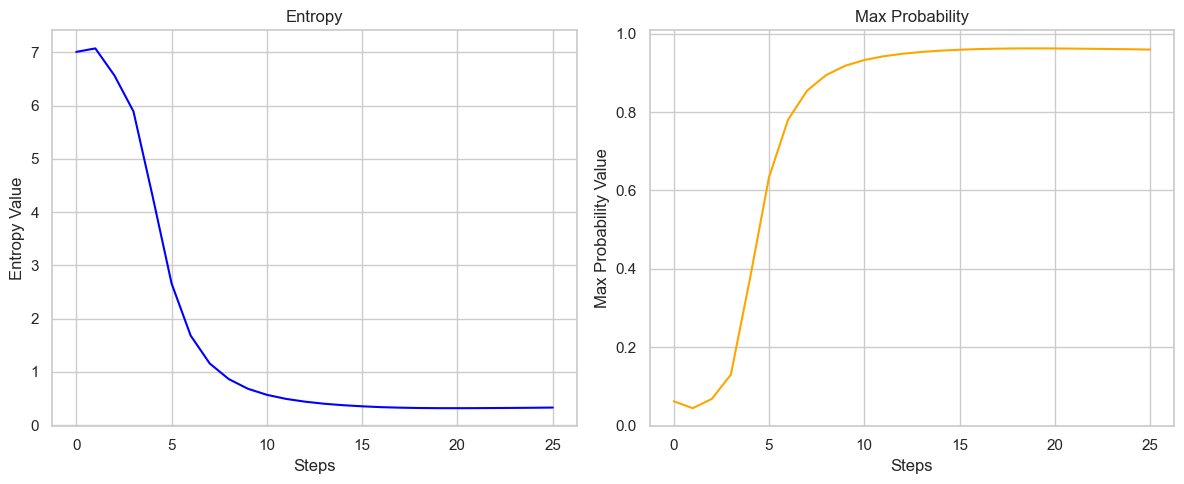

In [ ]:
pattern = 'b b b b b b b b b b b b b b b b b b b b b b b b b'
_ = run_model_on_pattern_and_plot(model, pattern)

['\n', '.', ' c', ' c', ' b', ' b', ' b', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a', ' b', ' a']


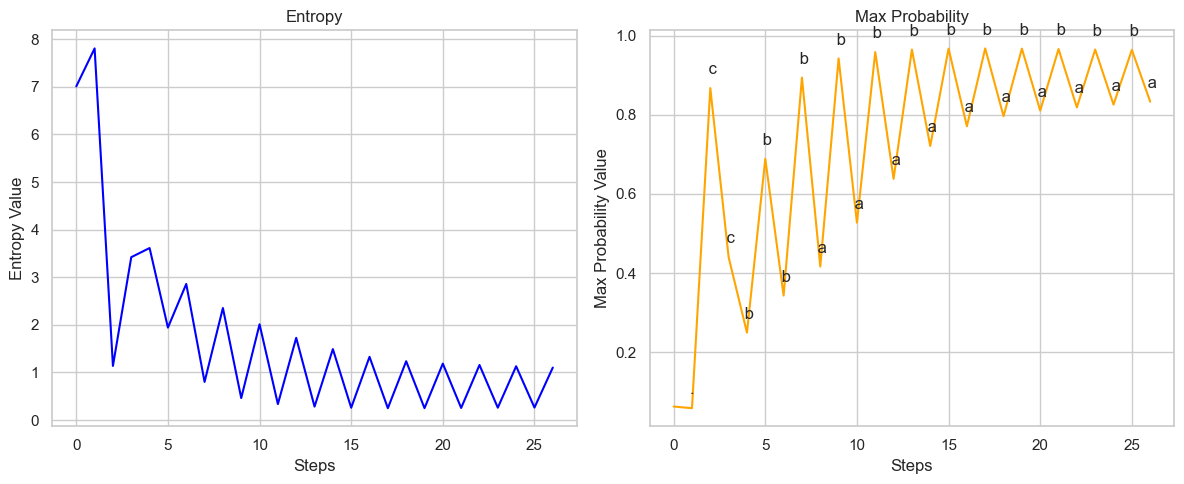

In [ ]:
pattern = 'a b a b a b a b a b a b a b a b a b a b a b a b a b'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

['\n', '1', ' -', ' -', ' +', ' -', ' +', ' -', ' +', ' -', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +', ' +']


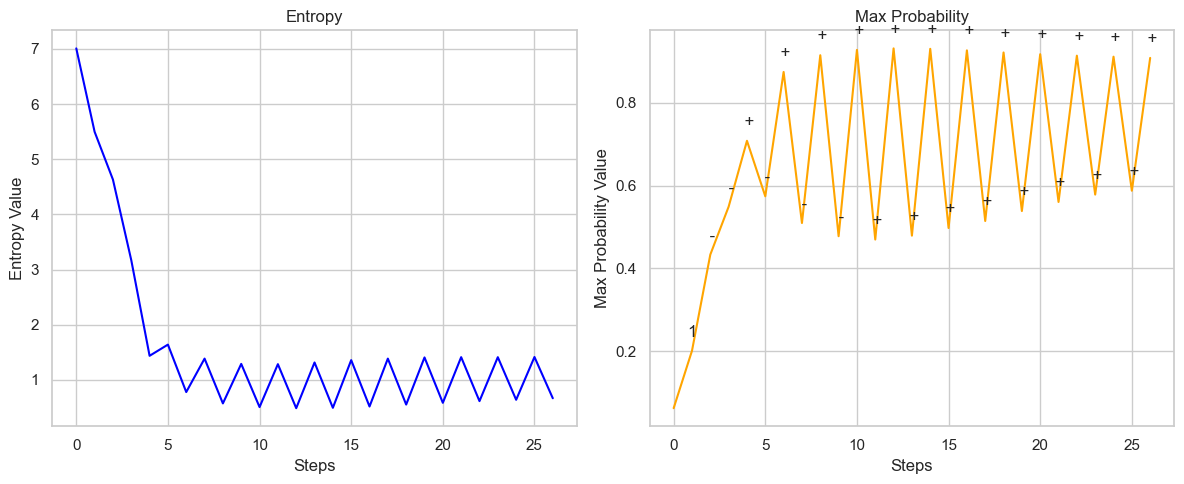

In [ ]:
pattern = '+ - + - + - + - + - + - + - + - + - + - + - + - + -'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

In [ ]:
patterns = ['a a a a a a a a a a a a a a a a a a a a a a a a a',
            'b b b b b b b b b b b b b b b b b b b b b b b b b',
            'a b a b a b a b a b a b a b a b a b a b a b a b a',
            'b a b a b a b a b a b a b a b a b a b a b a b a b',
            'A A A A A A A A A A A A A A A A A A A A A A A A A',
            'B B B B B B B B B B B B B B B B B B B B B B B B B',
            'B A B A B A B A B A B A B A B A B A B A B A B A B',
            'A B A B A B A B A B A B A B A B A B A B A B A B A',
            '+ - + - + - + - + - + - + - + - + - + - + - + - +',
            '- + - + - + - + - + - + - + - + - + - + - + - + -',
            '1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1',
            '2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2',
            '1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2',
            '2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1',
            'a1 a1 a1 a1 a1 a1 a1 a1 a1 a1 a1 a1 a1 a1 a1 a1', 
            'a2 a2 a2 a2 a2 a2 a2 a2 a2 a2 a2 a2 a2 a2 a2 a2',
            'a1 a2 a1 a2 a1 a2 a1 a2 a1 a2 a1 a2 a1 a2 a1 a2',
            'a2 a1 a2 a1 a2 a1 a2 a1 a2 a1 a2 a1 a2 a1 a2 a1',
            'a1 b1 a1 b1 a1 b1 a1 b1 a1 b1 a1 b1 a1 b1 a1 b1',
            'a2 b2 a2 b2 a2 b2 a2 b2 a2 b2 a2 b2 a2 b2 a2 b2',
            'a1 b2 a1 b2 a1 b2 a1 b2 a1 b2 a1 b2 a1 b2 a1 b2',
            'a2 b1 a2 b1 a2 b1 a2 b1 a2 b1 a2 b1 a2 b1 a2 b1']
losses = []
for pattern in patterns:
    loss = run_model_on_pattern(model, pattern, exclude_first_k=5)
    losses.append(loss)

pd.DataFrame({'pattern': [p[:20] for p in patterns], 'loss': losses})


,pattern,loss
0,a a a a a a a a a a,0.174511
1,b b b b b b b b b b,0.084359
2,a b a b a b a b a b,3.023973
3,b a b a b a b a b a,2.857765
4,A A A A A A A A A A,0.192118
5,B B B B B B B B B B,0.039090
6,B A B A B A B A B A,2.624557
7,A B A B A B A B A B,2.568133
8,+ - + - + - + - + -,1.922650
9,- + - + - + - + - +,2.023921


['\n', '.', 'b', '3', ' c', '3', ' b', '2', ' b', '2', ' b', '2', ' a', '2', ' b', '2', ' a', '2', ' b', '2', ' a', '2', ' b', '2', ' a', '2', ' b', '2', ' a', '2', ' b', '2', ' a']


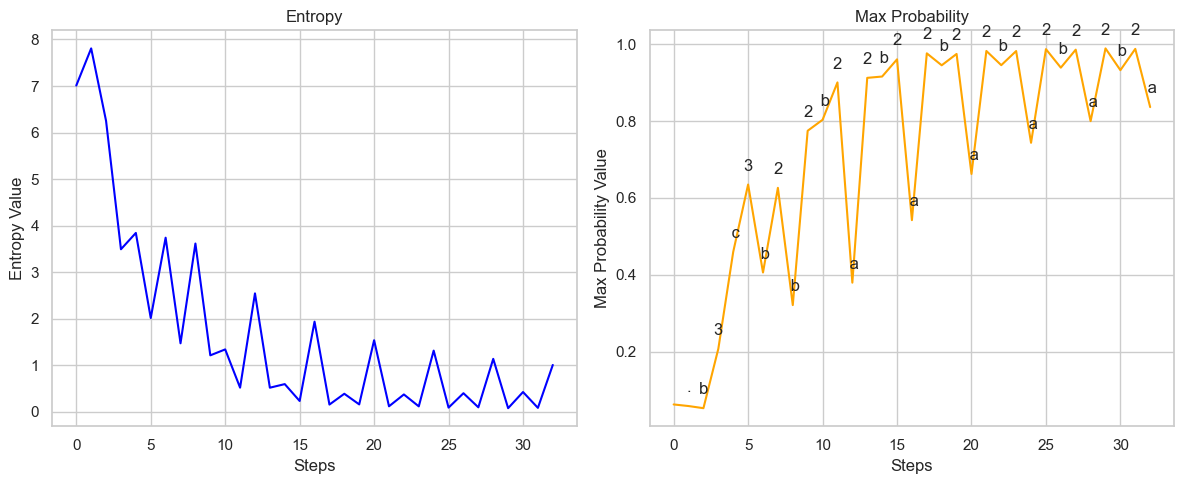

In [ ]:
pattern = 'a2 b2 a2 b2 a2 b2 a2 b2 a2 b2 a2 b2 a2 b2 a2 b2'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

In [ ]:
pattern = 'a1 b2 a1 b2 a1 b2 a1 b2 a1 b2 a1 b2 a1 b2 a1 b2'
_ = run_model_on_pattern_and_plot(model, pattern, annotate_tokens=True)

In [ ]:
# check that all symbols in patters match to a single token
symbols = ['a','b', '+', '-', 'A', 'B', '1', '2', '>', '<', '?', '!', '[', ']', '(', ')']
for symbol in symbols:
    if symbol not in model.tokenizer.get_vocab():
        print(f"Symbol {symbol} not found in tokens")

In [ ]:

# Function to tokenize patterns, run them through the model, and measure uncertainty
def run_model_on_pattern_and_plot(model, pattern, device):
    # Preprocess pattern
    tokens = pattern.replace("...", "").split()  # Split the pattern into individual tokens
    token_ids = model.to_tokens(tokens).to(device)  # Convert tokens to token ids
    token_ids = token_ids[:, :512]  # Limit the sequence length if necessary

    # Forward pass through the model
    logits, cache = model(token_ids, return_type="logits")
    
    # Calculate uncertainty (entropy over logits)
    softmax_logits = torch.nn.functional.softmax(logits, dim=-1)
    entropy = -torch.sum(softmax_logits * torch.log(softmax_logits + 1e-8), dim=-1)

    # Return uncertainty (logit entropy) for each step
    return entropy.cpu().detach().numpy()

# Run model on each pattern and register uncertainty
uncertainties = {}
for pattern in patterns:
    uncertainties[pattern] = run_model_on_pattern_and_plot(model, pattern, device)

# Display the uncertainties for each pattern
for pattern, uncertainty in uncertainties.items():
    print(f"Pattern: {pattern}\nUncertainty at each step:\n{uncertainty}\n")